In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from dl_permutations.models.symmetric_mlp import MLP
from dl_permutations.genetic_alg.ga import GA_TSP
from dl_permutations.genetic_alg.tsp import TSP

## Parameters

In [2]:
MODEL_SAVE_PATH = os.path.join('..', 'outputs', 'mlp_model.pt')

In [3]:
DATASET_SIZE = 1_000_000
TEST_RATIO = 0.2
VAL_RATIO = 0.2
BATCH_SIZE = 10_000
EPOCHS = 200
MAX_PATIENCE = 3
LR = 1e-3
WEIGHT_DECAY = 1e-3

In [4]:
rand_tsp_params = {
    'cities_count': 10,
    'min':0,
    'max':10,
    'start':1,
    'seed':21
}

## Generate a dataset of random permutations

In [5]:
tsp = TSP(**rand_tsp_params)

perm_rand = tsp.generate_solutions(DATASET_SIZE)
data = tsp.cities[perm_rand]
targets = np.apply_along_axis(tsp.total_distance,
                              axis=1, 
                              arr=perm_rand)
data.shape, targets.shape

((1000000, 9, 2), (1000000,))

In [6]:
test_idx = int(DATASET_SIZE *  (1-TEST_RATIO))
val_idx = int(test_idx *  (1-VAL_RATIO))

x_train = torch.tensor(data[:val_idx])
x_val = torch.tensor(data[val_idx:test_idx])
x_test = torch.tensor(data[test_idx:])

y_train = torch.tensor(targets[:val_idx])
y_val = torch.tensor(targets[val_idx:test_idx])
y_test = torch.tensor(targets[test_idx:])


train_loader = torch.utils.data.DataLoader(
                    torch.utils.data.TensorDataset(x_train, y_train),
                    shuffle = True,
                    batch_size=BATCH_SIZE
)
val_loader = torch.utils.data.DataLoader(
                    torch.utils.data.TensorDataset(x_val, y_val),
                    batch_size=BATCH_SIZE,
                    shuffle = False
)
test_loader = torch.utils.data.DataLoader(
                    torch.utils.data.TensorDataset(x_test, y_test),
                    batch_size=BATCH_SIZE,
                    shuffle = False
)

## Train a symmetric mlp network

In [7]:
input_len = data.shape[2]*data.shape[1]

model_params = {
    'encoder_sizes':[input_len, input_len*2, input_len*2],
    'decoder_sizes':[input_len, 1],
    'activations':[torch.nn.ReLU(), torch.nn.ReLU(),torch.nn.ReLU(), torch.nn.Identity()],
    'bias':True
}   

In [8]:
model = MLP(**model_params)
model.to(model.device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = torch.nn.MSELoss()

In [9]:
loss_history = []
patience = 0
best_loss = np.inf

for epoch in range(EPOCHS):
    avg_loss = 0
    for ft,tg in train_loader:
        ft = ft.to(model.device)
        tg = tg.to(model.device)

        embeddings = model.encode(ft)
        outputs = model.decode(embeddings)
        
        loss = criterion(outputs, tg)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item()

    loss_history.append(avg_loss/len(train_loader))

    if epoch % 5 == 0:
        val_loss = 0
        for ft, tg in val_loader:
            ft = ft.to(model.device)
            tg = tg.to(model.device)

            embeddings = model.encode(ft)
            outputs = model.decode(embeddings)

            val_loss += criterion(outputs, tg)

        if val_loss.item() < best_loss:
            patience = 0
            best_loss = val_loss.item()
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
        else:
            patience += 1

        if patience == MAX_PATIENCE:
            break

        print(f">>Epoch {epoch} Validation loss: {val_loss.item()/len(val_loader)} Patience: {patience}")

C:\Users\aszki\DL_Permutations\.venv\Lib\site-packages\torch\nn\modules\loss.py:630: UserWarning: Using a target size (torch.Size([10000])) that is different to the input size (torch.Size([10000, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


>>Epoch 0 Validation loss: 830.7624187476329 Patience: 0


>>Epoch 5 Validation loss: 40.088516929779345 Patience: 0


>>Epoch 10 Validation loss: 38.762764987909954 Patience: 0


>>Epoch 15 Validation loss: 38.75438225768208 Patience: 0


>>Epoch 20 Validation loss: 38.75428377737886 Patience: 0


>>Epoch 25 Validation loss: 38.75382372223979 Patience: 0


>>Epoch 30 Validation loss: 38.75631737888589 Patience: 1


>>Epoch 35 Validation loss: 38.77514731434353 Patience: 2


## Evaluation

In [10]:
with open(MODEL_SAVE_PATH, 'rb') as f:
    best_model = MLP(**model_params)
    best_model.load_state_dict(torch.load(f))
    best_model.to(model.device)

In [11]:
avg_loss = 0
test_outputs = []
test_emb = []
for ft,val in test_loader:
    ft = ft.to(model.device)
    val = val.to(model.device)

    embeddings = best_model.encode(ft)
    outputs = best_model.decode(embeddings)
    
    loss = criterion(outputs, val)
    avg_loss += loss.item()

    test_outputs.append(outputs.detach().cpu().numpy())
    test_emb.append(embeddings.detach().cpu().numpy())

test_outputs = np.concatenate(test_outputs)
test_emb = np.concatenate(test_emb)
print(f"Test loss: {avg_loss/len(test_loader)}")

Test loss: 38.928014347289455


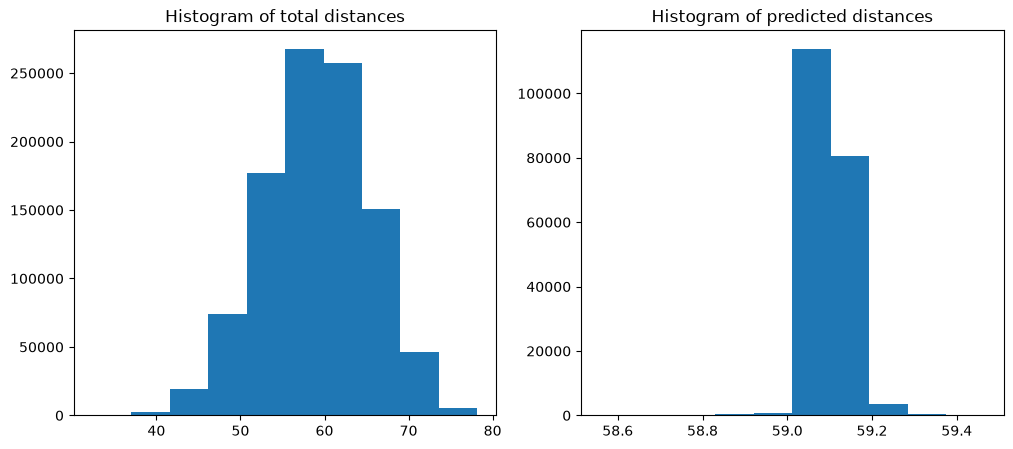

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(targets)
plt.title("Histogram of total distances")
plt.subplot(1,2,2)
plt.hist(np.array(test_outputs).flatten())
plt.title("Histogram of predicted distances")
plt.show()

In [13]:
worst_cases = np.argsort(np.abs(y_test - np.array(test_outputs).flatten()))[:5]
best_cases = np.argsort(np.abs(y_test - np.array(test_outputs).flatten()))[-5:]

C:\Users\aszki\AppData\Local\Temp\ipykernel_3268\2982336559.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worst_cases = np.argsort(np.abs(y_test - np.array(test_outputs).flatten()))[:5]
C:\Users\aszki\AppData\Local\Temp\ipykernel_3268\2982336559.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  best_cases = np.argsort(np.abs(y_test - np.array(test_outputs).flatten()))[-5:]


In [14]:
def draw_solution(perm_idx):
    plt.figure(figsize=(5,5))
    plt.scatter(x_test[perm_idx, :, 0], x_test[perm_idx, :, 1])
    plt.plot(x_test[perm_idx, :, 0], x_test[perm_idx, :, 1])
    plt.title('Solution: ' + str(perm_idx))
    plt.show()
        

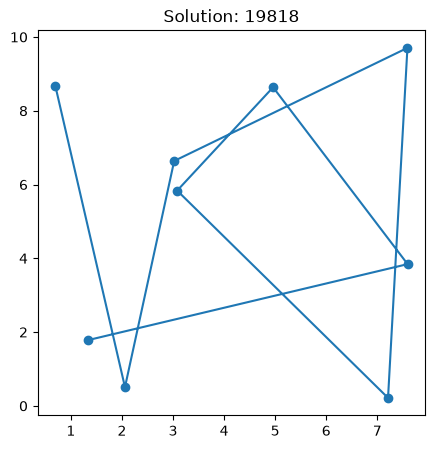

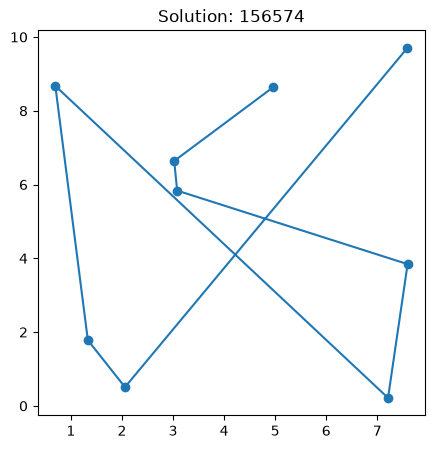

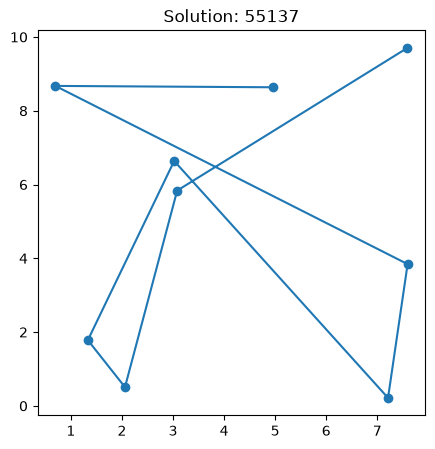

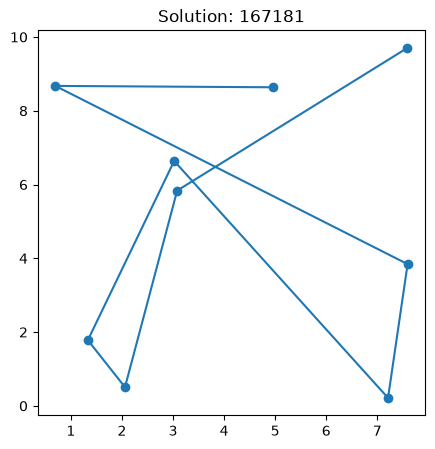

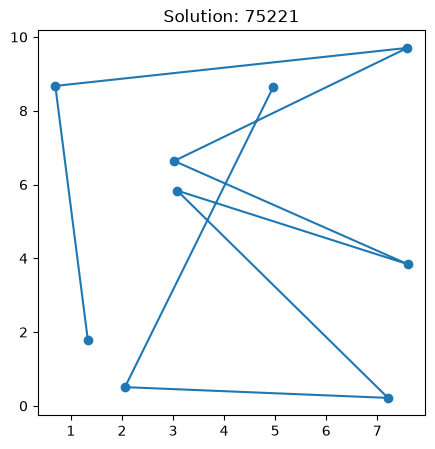

In [15]:
for c in worst_cases:
    draw_solution(c.item())

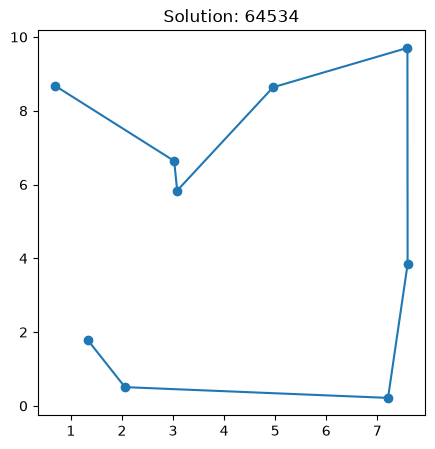

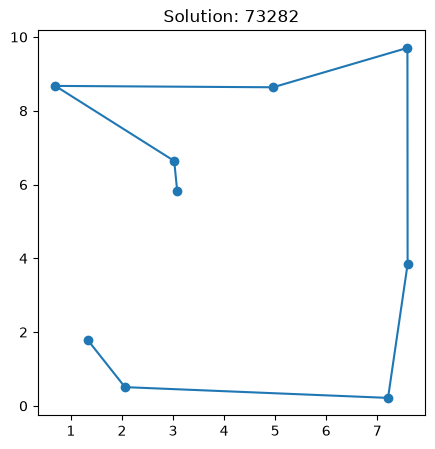

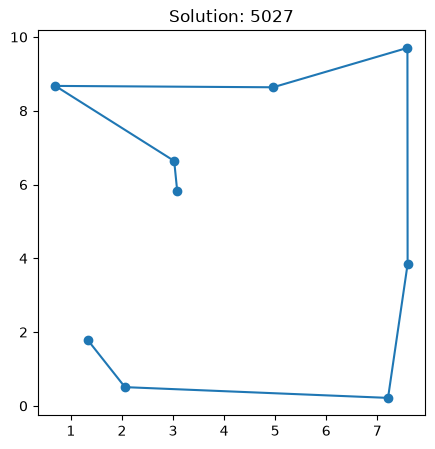

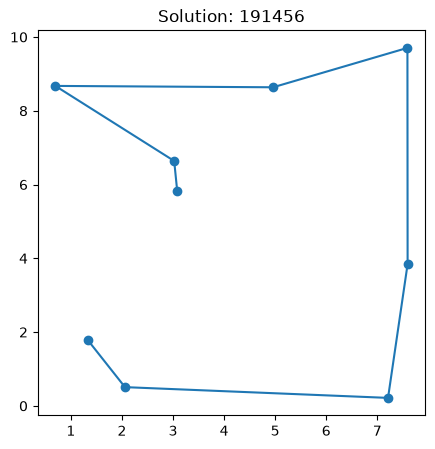

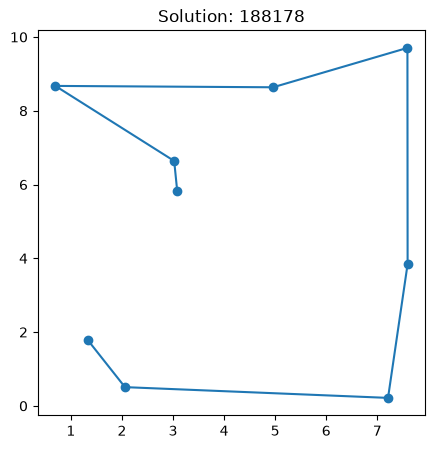

In [16]:
for c in best_cases:
    draw_solution(c.item())

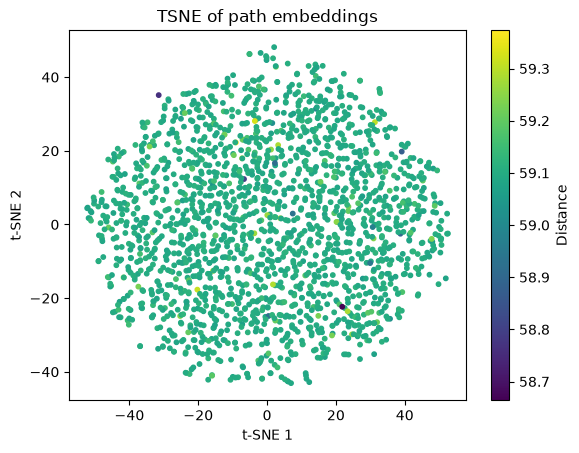

In [17]:
tsne = TSNE(
    n_components=2, 
    perplexity=30,
    random_state=42,
    max_iter=1000
)
X_tsne = tsne.fit_transform(test_emb[5_000:7_000])
scatter = plt.scatter(X_tsne[:, 0], 
            X_tsne[:, 1], 
            s=10,
            c=test_outputs[:2000].flatten(),
            cmap='viridis')
plt.colorbar(scatter, label='Distance')
plt.title('TSNE of path embeddings')
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()